# 04 — Scenario semantics: what does the Fed table *mean*?

Three readings of the same severely adverse anchor, through the same satellite:

- **do(unemployment)** — impose the path; the rest responds only through the
  graph's directed edges (Pearl's intervention).
- **observe(unemployment)** — condition on the path; the rest also updates
  through every historical correlation (exact Gaussian conditional simulation).
- **conditional** — take the whole published table as given (standard practice).


In [1]:
import os, sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Find the folder that contains the `multistate` package (works from
# bl225msc/ or from a self-contained thesis_demo/ bundle).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "multistate").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if (ROOT / "data" / "fed").is_dir():
    os.environ.setdefault("THESIS_DATA_DIR", str(ROOT / "data"))
RESULTS = ROOT / "results"
print(f"root: {ROOT}")

def load_csv(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    return pd.read_csv(path)

def load_pickle(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    with path.open("rb") as fh:
        return pickle.load(fh)

root: c:\Users\user\OneDrive\Desktop\thesis_clean\bl225msc\thesis_demo


In [2]:
fam = load_csv(RESULTS / "scengen" / "frontier_semantics3" / "path_family_summary.csv",
               "scenarios --semantics \"conditional;observe:unemployment;do:unemployment\" then frontier --paths ...")
if fam is not None:
    fam = fam.copy()
    fam["semantics"] = np.where(fam["generator"].str.contains("_do_"), "do(unemp)",
                        np.where(fam["generator"].str.contains("_obs_"), "observe(unemp)", "conditional"))
    fam["family"] = fam["generator"].str.replace(r"_(do|obs)_u$", "", regex=True)
    table = fam.pivot_table(index="family", columns="semantics", values="pd_h12_median")
    display((table[["conditional", "observe(unemp)", "do(unemp)"]] * 100).round(2))
    print("Fed severe anchor: 19.40% H12 PD")

semantics,conditional,observe(unemp),do(unemp)
family,,,
graph_block,20.07,13.07,12.25
graph_gaussian,21.48,13.42,12.19


Fed severe anchor: 19.40% H12 PD


**The decomposition.** do ~12%, observe ~13%, full table ~20–21%. The pure
intervention/observation gap is small (~1pp); the dominant ~7pp comes from
co-movements the table asserts **beyond** both causal propagation and historical
correlation with its own unemployment path — scenario severity is a co-movement
design choice, now quantified.

,generator,anchor_pd_h12,anchor_el_rate_h12,anchor_plausibility_loglik,anchor_severity_percentile,anchor_plausibility_percentile,sample_pd_h12_median,sample_pd_h12_p95,sample_pd_h12_max
0,graph_gaussian,0.194,0.011,-200.662,0.39,1.00,0.215,0.433,0.502
1,graph_gaussian_obs_u,0.194,0.011,-200.662,1.00,0.00,0.134,0.150,0.162
2,graph_gaussian_do_u,0.194,0.011,-200.662,1.00,0.00,0.122,0.135,0.160
3,graph_block,0.194,0.011,-200.662,0.44,0.94,0.201,0.363,0.472
4,graph_block_obs_u,0.194,0.011,-200.662,1.00,0.00,0.131,0.151,0.179
5,graph_block_do_u,0.194,0.011,-200.662,1.00,0.00,0.122,0.139,0.147


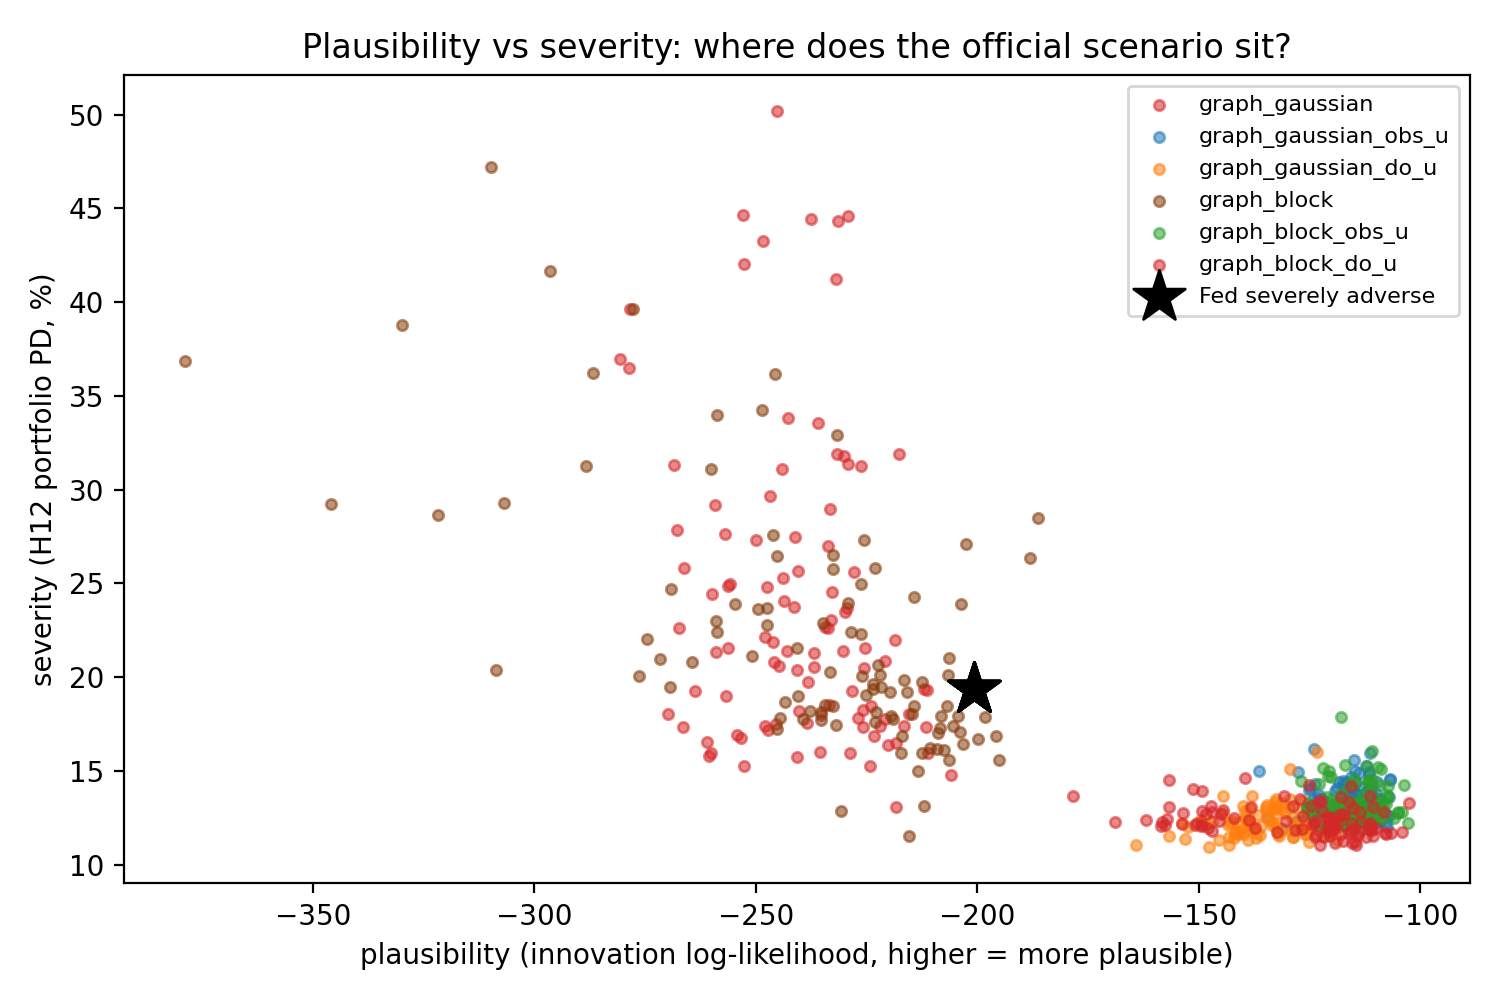

In [3]:
pos = load_csv(RESULTS / "scengen" / "frontier_semantics3" / "anchor_positions.csv", "same frontier run")
if pos is not None:
    display(pos.round(3))
frontier_csv = RESULTS / "scengen" / "frontier_semantics3" / "frontier_paths.csv"
if frontier_csv.exists():
    from multistate.scengen.plots import plot_frontier
    fig_dir = RESULTS / "scengen" / "figures"; fig_dir.mkdir(parents=True, exist_ok=True)
    plot_frontier(frontier_csv, fig_dir)
    display(Image(str(fig_dir / "fig_frontier.png"), width=680))

## Robustness: not an artifact of one graph or one instrument

In [4]:
dist = load_csv(RESULTS / "scengen" / "graph_robustness" / "semantics_gap_distribution.csv",
                "python -m multistate.scengen.graph_robustness --n-graphs 50 --n-paths 100 --out results/scengen/graph_robustness")
if dist is not None:
    gaps = dist["gap_cum_hpi_change"]
    plt.figure(figsize=(6, 3)); plt.hist(gaps, bins=15, color="#1f77b4", alpha=0.85)
    plt.axvline(0, color="black", lw=1)
    plt.xlabel("conditional minus do: 12q cumulative HPI gap (pp)"); plt.ylabel("bootstrap graphs")
    plt.title(f"Sign agreement across {len(gaps)} bootstrap graphs: "
              f"{(np.sign(gaps) == np.sign(gaps.median())).mean():.0%}")
    plt.tight_layout(); plt.show()
rep = load_csv(RESULTS / "scengen" / "graph_robustness" / "representative_satellite_gap.csv",
               "frontier --paths results/scengen/graph_robustness/rep_{low,med,high}")
if rep is not None:
    display(rep)

C:\Users\user\AppData\Local\Temp\ipykernel_38276\1490387675.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


,representative,conditional_generator,do_generator,conditional_median_pd,do_median_pd,pd_gap_pp,conditional_p95_pd,do_p95_pd,conditional_median_loglik,do_median_loglik
0,rep_low,g42,g42_do,0.192137,0.113124,7.901299,0.230756,0.120039,-228.568159,-155.353207
1,rep_med,g12,g12_do,0.188937,0.125904,6.303283,0.354525,0.132125,-223.272508,-120.029020
2,rep_high,g21,g21_do,0.191326,0.138340,5.298566,0.396051,0.168425,-231.305272,-123.617402


**Takeaways.** The ordering do < observe < conditional holds across two
generator families, three satellite instruments, and 50 bootstrap-resampled
graphs (PD gap 5.3–7.9pp across representative structures). The headline is a
property of the scenarios, not of any single estimated model.